# House Price Prediction Model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Set plot style
sns.set(style="whitegrid")


In [ ]:
# load dataset
df = pd.read_csv('data/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_va

# Handle missing values
## if we are considering meadian value bcoz when data like[1,2,3,4,4,5,300] if it look like outlier then we can take median, then mean will be totally out of the range

In [ ]:
# df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())
# or
df = df.dropna(subset=['total_bedrooms'])
df.isnull().sum()
# df['total_bedrooms'].value_counts()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Using Label encoder for encoding the categorical data
## Encoding Categorical Data
### 'ocean_proximity' is a categorical column. We can use Label Encoding for simplicity or One-Hot Encoding.

In [6]:
print("\nUnique values in ocean_proximity:", df['ocean_proximity'].unique())
# so here we have to make the this cateroical value to numeric value using label encoder


Unique values in ocean_proximity: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [7]:
# Using Label Encoder
le = LabelEncoder()
df['ocean_proximity_encoded'] = le.fit_transform(df['ocean_proximity'])

# Drop the original categorical column for correlation analysis and modeling
df_model = df.drop('ocean_proximity', axis=1)

print("\nData after preprocessing:")
df_model.head()



Data after preprocessing:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


## 1. Heatmap using Correlation Matrix


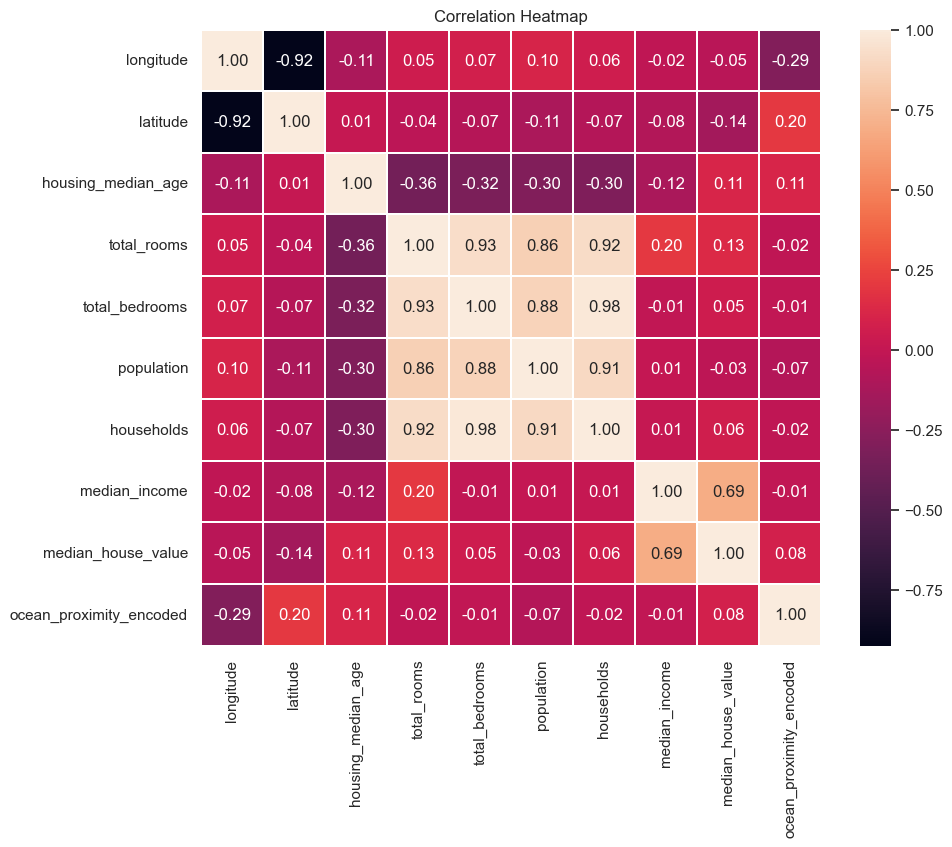

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_model.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.2)
plt.title('Correlation Heatmap')
plt.show()


## 2. Scatter Graph

Visualizing the relationship between Median Income and Median House Value (usually the strongest correlation).


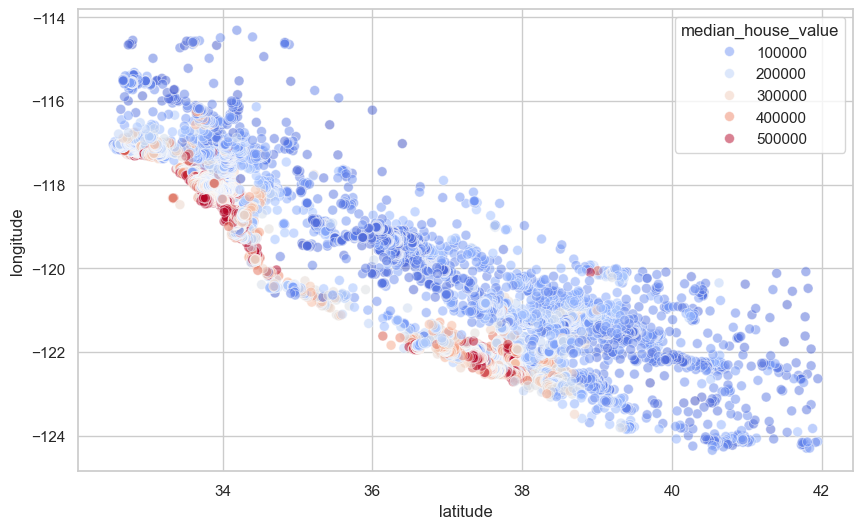

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='latitude', y='longitude', hue='median_house_value',palette='coolwarm', data=df, alpha=0.5,s=50)
plt.show()
# it shows the relationship between latitude and longitude and the median house value 
# means more red color shows price is high as their in the costal side

## Data Splitting


In [10]:
# Define features (X) and target (y)
X = df_model.drop('median_house_value', axis=1)
y = df_model['median_house_value']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (16346, 9)
Test set shape: (4087, 9)


In [11]:
X.isnull().sum()

longitude                  0
latitude                   0
housing_median_age         0
total_rooms                0
total_bedrooms             0
population                 0
households                 0
median_income              0
ocean_proximity_encoded    0
dtype: int64

## 1. Simple Linear Regression

Using Linear Regression for training the model.


In [12]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"RMSE: {rmse_lr}")
print(f"R2 Score: {r2_lr}")


Linear Regression Results:
RMSE: 70171.99539639696
R2 Score: 0.6399236679243399


## 2. Random Forest Regression

Using Random Forest for prediction.


In [13]:
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"RMSE: {rmse_rf}")
print(f"R2 Score: {r2_rf}")


Random Forest Results:
RMSE: 49489.14219085517
R2 Score: 0.8209036331508458


## 3. XGBoost Regression

Using XGBoost for prediction.


In [14]:
# Initialize and train the model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"RMSE: {rmse_xgb}")
print(f"R2 Score: {r2_xgb}")


XGBoost Results:
RMSE: 49709.556210544164
R2 Score: 0.8193047669855901


## Model Comparison


               Model          RMSE  R2 Score
1      Random Forest  49489.142191  0.820904
2            XGBoost  49709.556211  0.819305
0  Linear Regression  70171.995396  0.639924


C:\Users\Krithik Naidu\AppData\Local\Temp\ipykernel_28540\2788152744.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=models, palette='viridis')


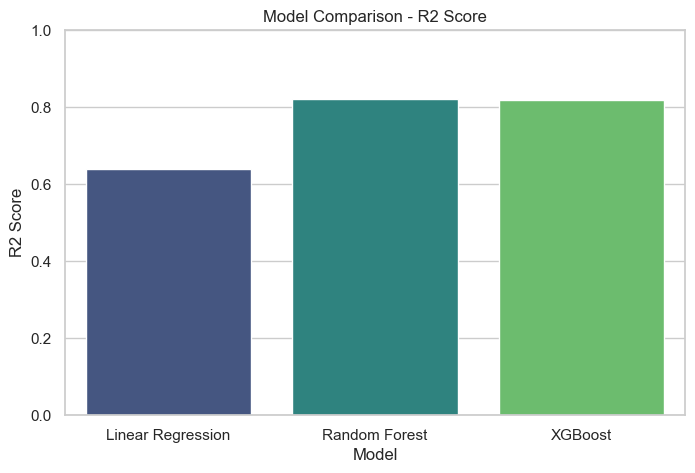

In [15]:
models = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2 Score': [r2_lr, r2_rf, r2_xgb]
})

print(models.sort_values(by='R2 Score', ascending=False))

# Bar plot of R2 Scores
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=models, palette='viridis')
plt.title('Model Comparison - R2 Score')
plt.ylim(0, 1)
plt.show()


# creating PKL file 

In [16]:
# Save the model and encoder
import joblib
import os

# Create directory if not exists
os.makedirs('PKL_files', exist_ok=True)

# Save the Random Forest model and Label Encoder
joblib.dump(rf_model, 'PKL_files/rf_model.pkl')
joblib.dump(le, 'PKL_files/label_encoder.pkl')

print("Model and Label Encoder saved successfully to 'PKL_files'")


Model and Label Encoder saved successfully to 'PKL_files'
